*In this notebook, we check the imports for pySPEDAS and relevant functionalities. We download a sample set of FGM data and do some basic plotting.*

Check pySPEDAS is installed and is imported correctly:

In [13]:
import pyspedas
print(pyspedas)

<module 'pyspedas' from '/Users/yulun/artemis-lunar-plasma/.venv/lib/python3.12/site-packages/pyspedas/__init__.py'>


In [14]:
import pyspedas.projects as projects

print(dir(projects))


['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'ace', 'akebono', 'barrel', 'cluster', 'cnofs', 'csswe', 'de2', 'dscovr', 'elfin', 'equator_s', 'erg', 'fast', 'geotail', 'goes', 'image', 'kompsat', 'kyoto', 'lanl', 'maven', 'mica', 'mms', 'noaa', 'omni', 'poes', 'polar', 'psp', 'rbsp', 'secs', 'soho', 'solo', 'st5', 'stereo', 'swarm', 'themis', 'twins', 'ulysses', 'wind']


Check ARTEMIS data can be imported correctly under themis header, and that FGM data can be accessed for probe B for some arbitrary time range:

In [15]:
from pyspedas.projects import themis

trange = ['2011-02-20', '2011-02-21'] #timestamps in UTC

themis.fgm(
    trange=trange,
    probe='b'
)

27-Jun-26 20:17:22: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thb/l2/fgm/2011/
27-Jun-26 20:17:26: File is current: themis_data/thb/l2/fgm/2011/thb_l2_fgm_20110220_v01.cdf


['thb_fgs_btotal',
 'thb_fgs_gse',
 'thb_fgs_gsm',
 'thb_fgs_dsl',
 'thb_fgl_btotal',
 'thb_fgl_gse',
 'thb_fgl_gsm',
 'thb_fgl_dsl',
 'thb_fgl_ssl',
 'thb_fgh_btotal',
 'thb_fgh_gse',
 'thb_fgh_gsm',
 'thb_fgh_dsl',
 'thb_fgh_ssl']

Tplot is a scientific data management and plotting system, where variables store numbers and metadata.

PySPEDAS retrieves data files from NASA archives, loads them into tplot's in-memory data store, and then assigns each dataset a variable name which can be used to access it:

In [16]:
import matplotlib.pyplot as plt
from pyspedas import tplot, get_data, tplot_names, del_data

# clean tplot memory first, i.e. delete all tplot variables currently stored
del_data()

trange = ['2011-02-20', '2011-02-21'] #download data between these two UTC timestamps

#download THEMIS FGM data using PySPEDAS
vars_loaded = themis.fgm( 
    trange=trange,
    probe='b'
)

print("Variables returned by themis.fgm():")
print(vars_loaded)

print("\nVariables currently stored in tplot memory:")
print(tplot_names())

27-Jun-26 20:17:26: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thb/l2/fgm/2011/
27-Jun-26 20:17:28: File is current: themis_data/thb/l2/fgm/2011/thb_l2_fgm_20110220_v01.cdf


Variables returned by themis.fgm():
['thb_fgs_btotal', 'thb_fgs_gse', 'thb_fgs_gsm', 'thb_fgs_dsl', 'thb_fgl_btotal', 'thb_fgl_gse', 'thb_fgl_gsm', 'thb_fgl_dsl', 'thb_fgl_ssl', 'thb_fgh_btotal', 'thb_fgh_gse', 'thb_fgh_gsm', 'thb_fgh_dsl', 'thb_fgh_ssl']

Variables currently stored in tplot memory:
0 : thb_fgs_btotal
1 : thb_fgs_gse
2 : thb_fgs_gsm
3 : thb_fgs_dsl
4 : thb_fgl_btotal
5 : thb_fgl_gse
6 : thb_fgl_gsm
7 : thb_fgl_dsl
8 : thb_fgl_ssl
9 : thb_fgh_btotal
10 : thb_fgh_gse
11 : thb_fgh_gsm
12 : thb_fgh_dsl
13 : thb_fgh_ssl
['thb_fgs_btotal', 'thb_fgs_gse', 'thb_fgs_gsm', 'thb_fgs_dsl', 'thb_fgl_btotal', 'thb_fgl_gse', 'thb_fgl_gsm', 'thb_fgl_dsl', 'thb_fgl_ssl', 'thb_fgh_btotal', 'thb_fgh_gse', 'thb_fgh_gsm', 'thb_fgh_dsl', 'thb_fgh_ssl']


After having loaded variables e.g. THEMIS FGM for probe B, can get raw data from variables as a tuple by using get_data().

get_data() takes as input the name of a single dataset.

In [19]:
data = get_data("thb_fgl_gse") #input is a name, not vars_loaded

print(data)

print ("size of tuple is", len(data))

variable(times=array([1.29818170e+09, 1.29818170e+09, 1.29818170e+09, ...,
       1.29820385e+09, 1.29820385e+09, 1.29820385e+09], shape=(88576,)), y=array([[-9.447426 ,  1.1149547,  1.3382565],
       [-9.431756 ,  1.0846987,  1.3655378],
       [-9.427928 ,  1.0700375,  1.3554672],
       ...,
       [-8.917713 , -1.4861436,  0.7631028],
       [-8.898117 , -1.5321305,  0.7383172],
       [-8.923518 , -1.5802753,  0.7324276]],
      shape=(88576, 3), dtype=float32), v=array([1, 2, 3], dtype=int32))
length of array is 3


The length of the tuple is 3, since get_data() typically returns (times, data values, metadata). Each is stores as a NumPy array.

For example, looking at the magnetic field data:

In [30]:
times, B, metadata = get_data("thb_fgl_gse")

print(type(times))
print(type(B))

print(times)
print("there are", len(times), "time values in a day.")

print(B)
print("there are", len(B), "magnetic field measurements in a day.")

print(metadata)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[1.29818170e+09 1.29818170e+09 1.29818170e+09 ... 1.29820385e+09
 1.29820385e+09 1.29820385e+09]
there are 88576 time values in a day.
[[-9.447426   1.1149547  1.3382565]
 [-9.431756   1.0846987  1.3655378]
 [-9.427928   1.0700375  1.3554672]
 ...
 [-8.917713  -1.4861436  0.7631028]
 [-8.898117  -1.5321305  0.7383172]
 [-8.923518  -1.5802753  0.7324276]]
there are 88576 magnetic field measurements in a day.
[1 2 3]


"times" contains Unix timestamps, in seconds since 1 Jan 1970 UTC.

"B" contains the 3 magnetic field components in nT in each of the 3 GSE (Geocentric Solar Ecliptic) axes.

The metadata stores components 1, 2, 3 (i.e. Bx, By, Bz).

The individual components can be accessed via NumPy slicing on the 2D array for "B" and plotted:

Text(0, 0.5, 'Bx (nT)')

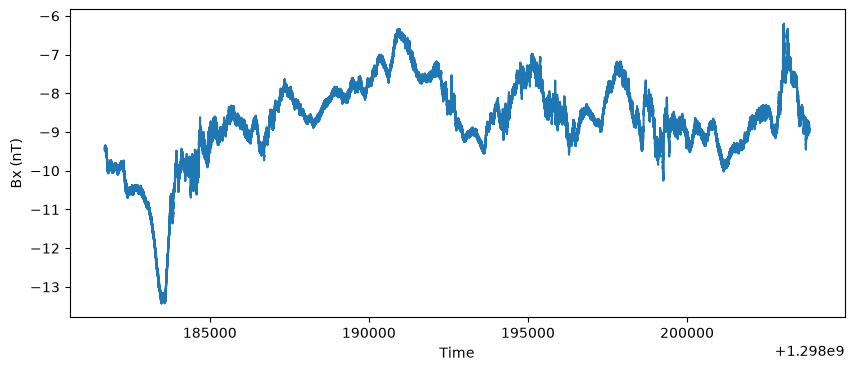

In [26]:
# slicing 2D array to get individual components
Bx = B[:,0] 
By = B[:,1]
Bz = B[:,2]

#plot Bx using ordinary matplotlib
plt.figure(figsize=(10,4))

plt.plot(times, Bx)

plt.xlabel("Time")
plt.ylabel("Bx (nT)")

Make the time readable using time_datetime, and plot all 3 B components against converted time:

[datetime.datetime(2011, 2, 20, 6, 1, 41, 907684, tzinfo=datetime.timezone.utc), datetime.datetime(2011, 2, 20, 6, 1, 42, 157684, tzinfo=datetime.timezone.utc), datetime.datetime(2011, 2, 20, 6, 1, 42, 407684, tzinfo=datetime.timezone.utc), datetime.datetime(2011, 2, 20, 6, 1, 42, 657684, tzinfo=datetime.timezone.utc), datetime.datetime(2011, 2, 20, 6, 1, 42, 907684, tzinfo=datetime.timezone.utc)]


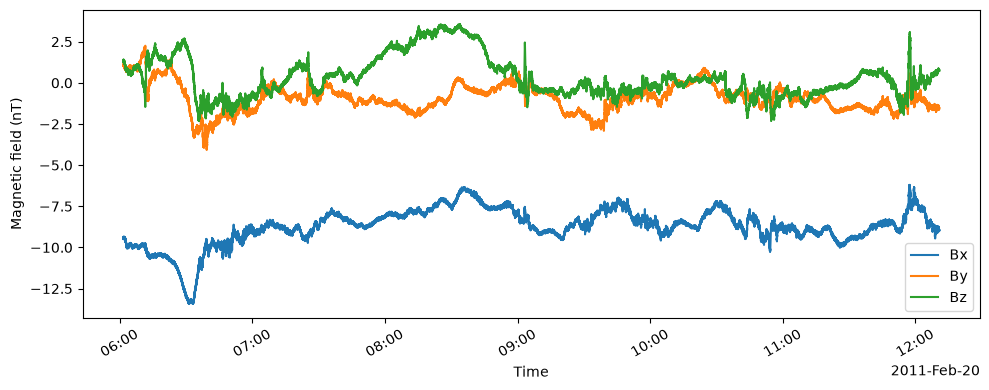

In [34]:
from pyspedas import time_datetime

dt = time_datetime(times)

print(dt[:5])

Bx = B[:, 0]
By = B[:, 1]
Bz = B[:, 2]

plt.figure(figsize=(10, 4))
plt.plot(dt, Bx, label="Bx")
plt.plot(dt, By, label="By")
plt.plot(dt, Bz, label="Bz")

plt.xlabel("Time")
plt.ylabel("Magnetic field (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Also can plot magnitude against time using thb_fgl_btotal:

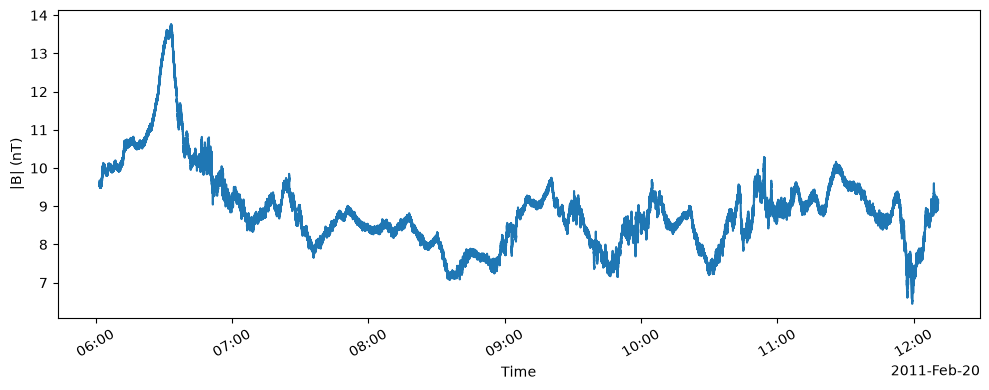

In [39]:
import numpy as np
time, Btotal_builtin = get_data("thb_fgl_btotal")

plt.figure(figsize=(10, 4))
plt.plot(dt, Btotal_builtin)

plt.xlabel("Time")
plt.ylabel("|B| (nT)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Plot B components and magnitude against time and look for anomalies:

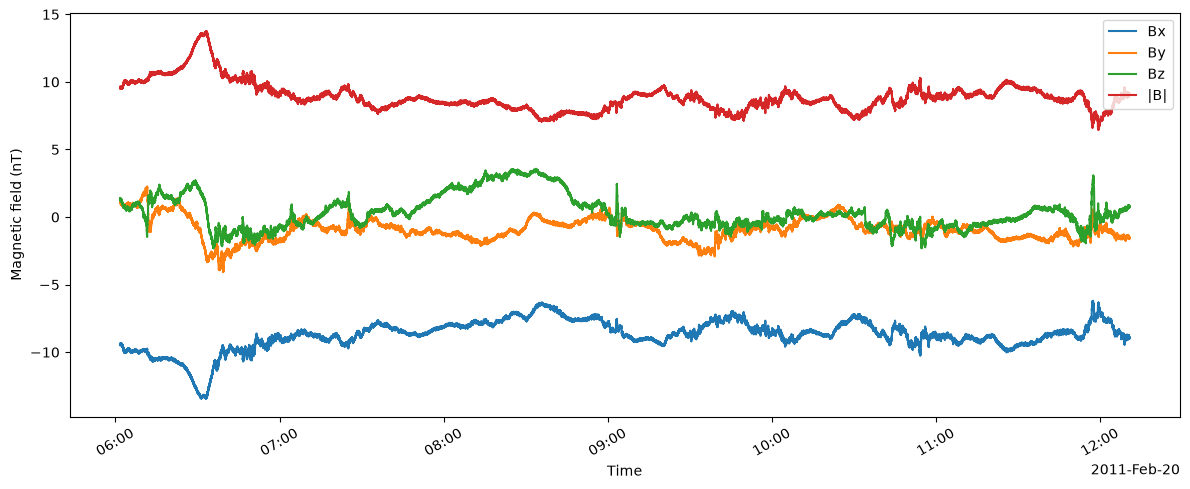

In [43]:
import pandas as pd

times, B, meta = get_data("thb_fgl_gse")

dt = time_datetime(times)

Bx = B[:, 0]
By = B[:, 1]
Bz = B[:, 2]
Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

df = pd.DataFrame({
    "time": dt,
    "Bx": Bx,
    "By": By,
    "Bz": Bz,
    "Bmag": Bmag
})

df.head()

plt.figure(figsize=(12, 5))
plt.plot(df["time"], df["Bx"], label="Bx")
plt.plot(df["time"], df["By"], label="By")
plt.plot(df["time"], df["Bz"], label="Bz")
plt.plot(df["time"], df["Bmag"], label="|B|")

plt.xlabel("Time")
plt.ylabel("Magnetic field (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
times_gse, B_gse, meta1 = get_data("thb_fgl_gse")
times_gsm, B_gsm, meta2= get_data("thb_fgl_gsm")

print(B_gse[:5])
print(B_gsm[:5])

[[-9.447426   1.1149547  1.3382565]
 [-9.431756   1.0846987  1.3655378]
 [-9.427928   1.0700375  1.3554672]
 [-9.398107   1.0905758  1.3943899]
 [-9.458634   1.0601197  1.4059396]]
[[-9.447426    0.64297825  1.618837  ]
 [-9.431756    0.6057384   1.6353427 ]
 [-9.427928    0.59494567  1.6212069 ]
 [-9.398107    0.602353    1.6645869 ]
 [-9.458634    0.56981987  1.6660808 ]]


Can plot azimuthal angle in GSE coordinates:

Text(0, 0.5, 'Azimuth angle (deg)')

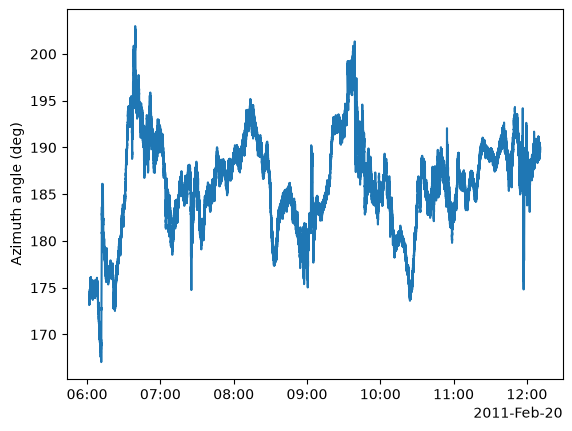

In [48]:
phi = np.degrees(
    np.arctan2(By, Bx)
)

phi_unwrapped = np.degrees(
    np.unwrap(np.radians(phi))
)

plt.plot(df["time"], phi_unwrapped)
plt.ylabel("Azimuth angle (deg)")

For fun, we can compare components of measured B field in GSE and GSM coordinate systems:

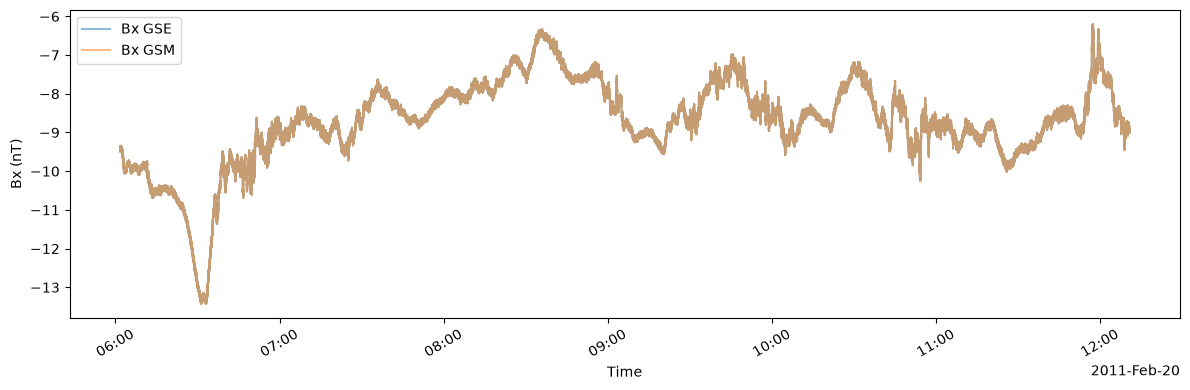

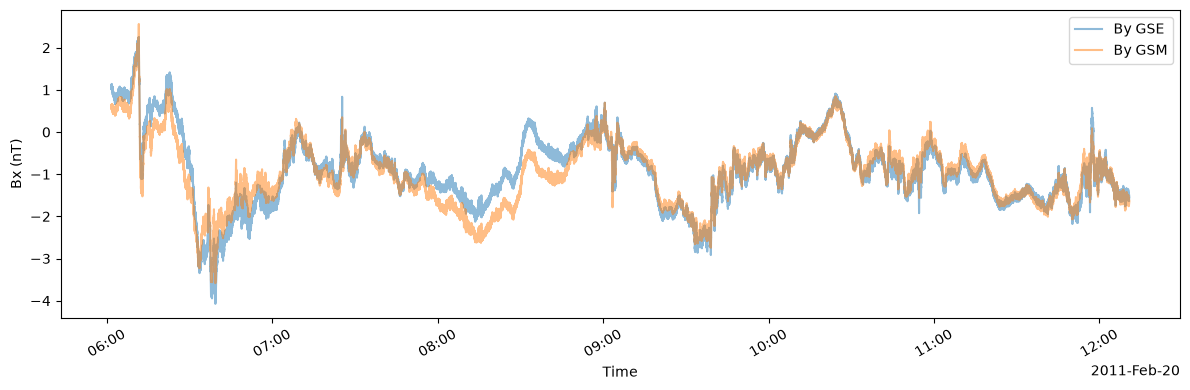

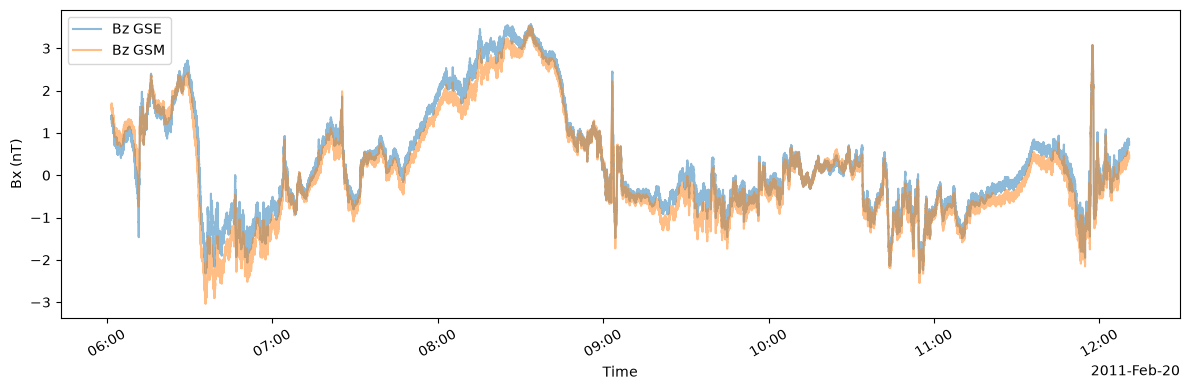

In [55]:
#get data for GSE and GSM coords
times_gse, B_gse, meta_gse = get_data("thb_fgl_gse")
times_gsm, B_gsm, meta_gsm= get_data("thb_fgl_gsm")

#use same timestamps
dt = time_datetime(times_gse)

Bx_gse, By_gse, Bz_gse = B_gse[:, 0], B_gse[:, 1], B_gse[:, 2]
Bx_gsm, By_gsm, Bz_gsm = B_gsm[:, 0], B_gsm[:, 1], B_gsm[:, 2]

#plot x-component
plt.figure(figsize=(12, 4))

plt.plot(dt, Bx_gse, label="Bx GSE", alpha=0.5)
plt.plot(dt, Bx_gsm, label="Bx GSM", linestyle="-", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Bx (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#plot y-component
plt.figure(figsize=(12, 4))

plt.plot(dt, By_gse, label="By GSE", alpha=0.5)
plt.plot(dt, By_gsm, label="By GSM", linestyle="-", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Bx (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#plot z-component
plt.figure(figsize=(12, 4))

plt.plot(dt, Bz_gse, label="Bz GSE", alpha=0.5)
plt.plot(dt, Bz_gsm, label="Bz GSM", linestyle="-", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Bx (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Can also plot component-wise differences:

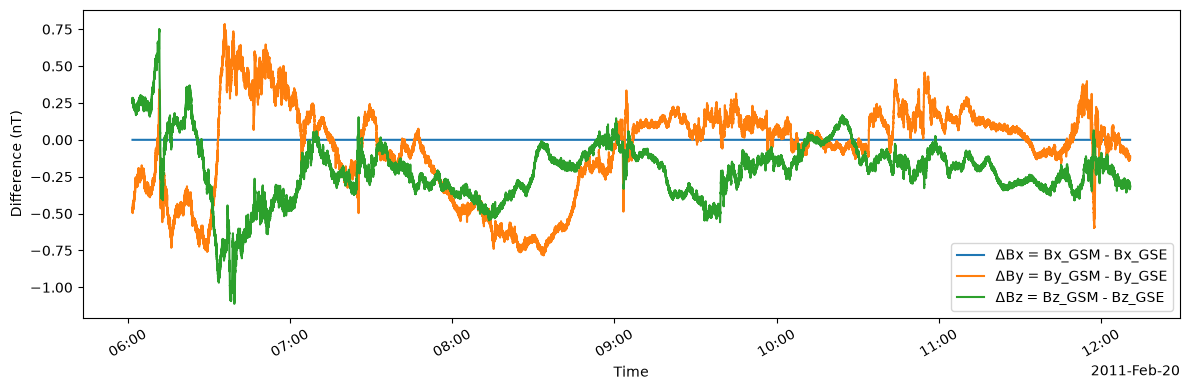

In [57]:
dB = B_gsm - B_gse

plt.figure(figsize=(12, 4))
plt.plot(dt, dB[:, 0], label="ΔBx = Bx_GSM - Bx_GSE")
plt.plot(dt, dB[:, 1], label="ΔBy = By_GSM - By_GSE")
plt.plot(dt, dB[:, 2], label="ΔBz = Bz_GSM - Bz_GSE")

plt.xlabel("Time")
plt.ylabel("Difference (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

As expected, Bx almost identical since X-axis invariant under coordinate transform from GSE to GSM. By and Bz differ since Y-Z plane is rotated.

Now compare with spacecraft coordinates, e.g. DSL:

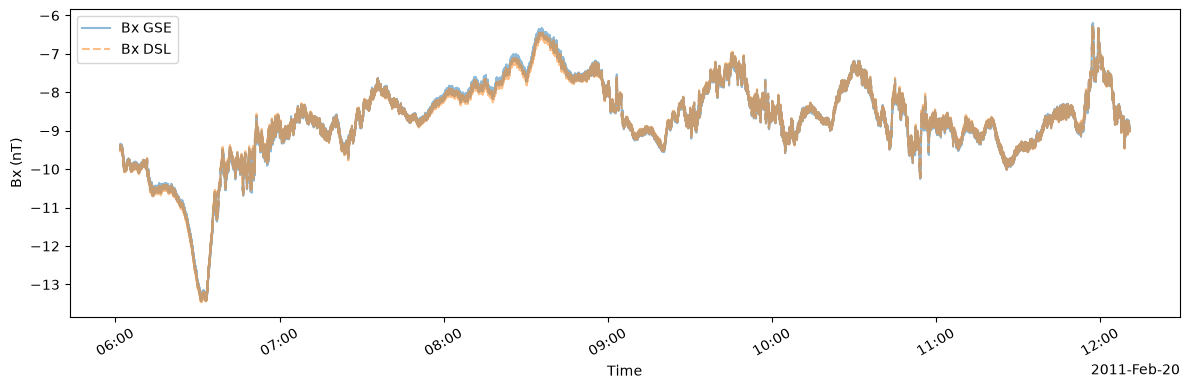

In [60]:
times_dsl, B_dsl, meta_dsl = get_data("thb_fgl_dsl")

plt.figure(figsize=(12, 4))
plt.plot(dt, B_gse[:, 0], label="Bx GSE", alpha=0.5)
plt.plot(dt, B_dsl[:, 0], label="Bx DSL", linestyle="--", alpha = 0.5)

plt.xlabel("Time")
plt.ylabel("Bx (nT)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Check component-wise:

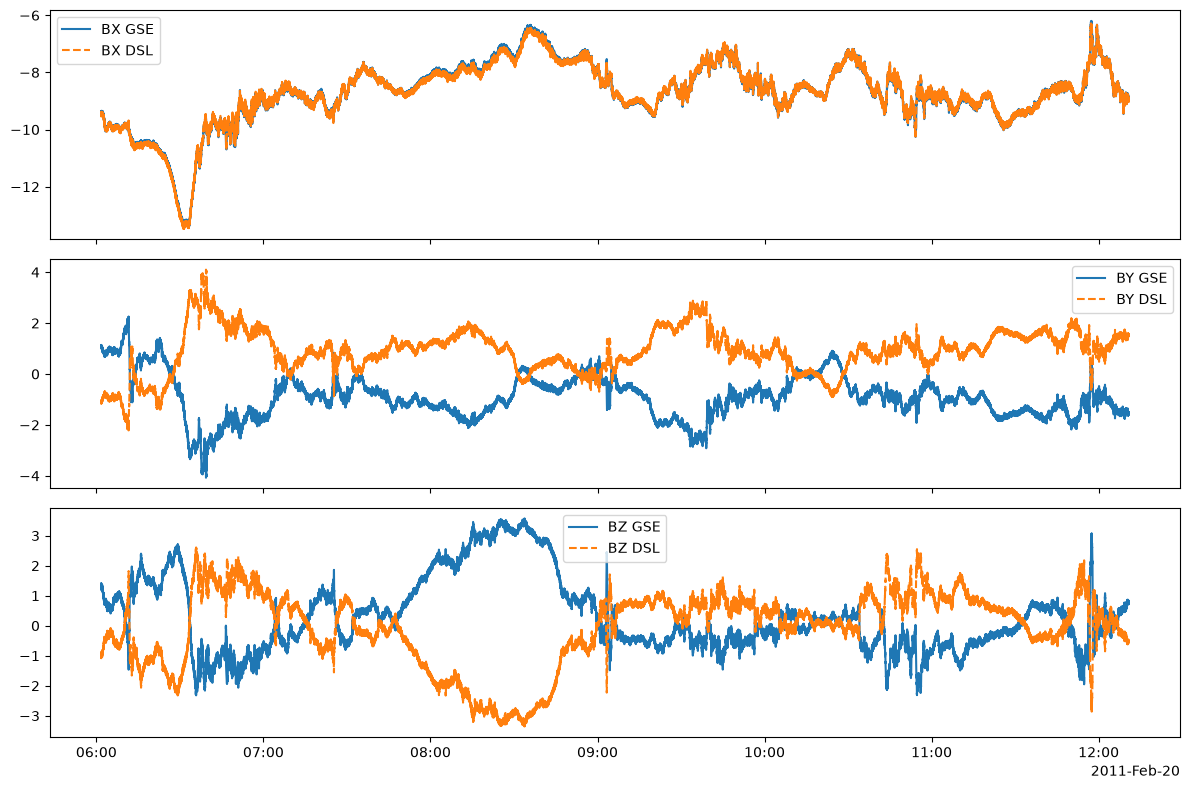

In [62]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

labels = ["X", "Y", "Z"]

for i in range(3):
    ax[i].plot(dt, B_gse[:, i], label=f"B{labels[i]} GSE")
    ax[i].plot(dt, B_dsl[:, i], "--", label=f"B{labels[i]} DSL")
    ax[i].legend()

plt.tight_layout()
plt.show()

Check correlation:

In [61]:
for i, comp in enumerate(["X", "Y", "Z"]):
    corr = np.corrcoef(B_gse[:, i], B_dsl[:, i])[0, 1]
    print(comp, corr)

X 0.9993940157279579
Y -0.9995354638652193
Z -0.9995359071589466


So spacecraft coordinates are rotated by $\frac{\pi}{2}$ about x-axis compared to GSE.

Now we move onto understanding the position of the spacecraft so we can interpret the magnetic field data meaningfully.

We use themis.state() to obtain ephemeris data:

In [63]:
# Load THEMIS-B state / position data for the same time range
state_vars = themis.state(
    trange=trange,
    probe="b"
)

print("State variables loaded:")
print(state_vars)

print("\nAll tplot variables now in memory:")
print(tplot_names())

28-Jun-26 23:37:28: Downloading https://themis.ssl.berkeley.edu/data/themis/thb/l1/state/2011/thb_l1_state_20110220.cdf to themis_data/thb/l1/state/2011/thb_l1_state_20110220.cdf
28-Jun-26 23:37:29: Download of themis_data/thb/l1/state/2011/thb_l1_state_20110220.cdf complete, 0.547 MB in 2.6 sec (0.207 MB/sec) (transfer_slow)


State variables loaded:
['thb_pos', 'thb_vel', 'thb_spin_initial_delta_phi', 'thb_spin_idpu_spinper', 'thb_spin_segflags', 'thb_spin_ecl_initial_delta_phi', 'thb_spin_ecl_idpu_spinper', 'thb_spin_ecl_segflags', 'thb_pos_gse', 'thb_pos_gsm', 'thb_vel_gse', 'thb_vel_gsm', 'thb_pos_sel', 'thb_pos_sse', 'thb_vel_sel', 'thb_vel_sse']

All tplot variables now in memory:
0 : thb_fgs_btotal
1 : thb_fgs_gse
2 : thb_fgs_gsm
3 : thb_fgs_dsl
4 : thb_fgl_btotal
5 : thb_fgl_gse
6 : thb_fgl_gsm
7 : thb_fgl_dsl
8 : thb_fgl_ssl
9 : thb_fgh_btotal
10 : thb_fgh_gse
11 : thb_fgh_gsm
12 : thb_fgh_dsl
13 : thb_fgh_ssl
14 : thb_pos
15 : thb_vel
16 : thb_spin_initial_delta_phi
17 : thb_spin_idpu_spinper
18 : thb_spin_segflags
19 : thb_spin_ecl_initial_delta_phi
20 : thb_spin_ecl_idpu_spinper
21 : thb_spin_ecl_segflags
22 : thb_pos_gse
23 : thb_pos_gsm
24 : thb_vel_gse
25 : thb_vel_gsm
26 : thb_pos_sel
27 : thb_pos_sse
28 : thb_vel_sel
29 : thb_vel_sse
['thb_fgs_btotal', 'thb_fgs_gse', 'thb_fgs_gsm', 'thb_fgs_

Inspecting position data first:

In [65]:
times_pos, R_gse, meta = get_data("thb_pos_gse")

print(type(R_gse))
print(R_gse.shape)

print(R_gse[:5])

<class 'numpy.ndarray'>
(1440, 3)
[[-315274.8    -92059.76   -27318.133]
 [-315263.66   -92101.91   -27319.127]
 [-315252.53   -92143.9    -27320.12 ]
 [-315241.34   -92186.016  -27321.113]
 [-315230.12   -92228.2    -27322.105]]
